In [ ]:
from typing import Annotated, TypedDict

import pandas as pd
from langchain_core.prompt_values import ChatPromptValue
from langchain_core.prompts import ChatPromptTemplate
from langchain_huggingface import ChatHuggingFace, HuggingFacePipeline
from langgraph.graph import END, START, StateGraph
from langgraph.graph.message import add_messages
from transformers import pipeline

from src.extractors.extractor import PllumExtractor
from src.make_paths_relative_to_root import *


class State(TypedDict):
    messages: Annotated[list, add_messages]

In [ ]:
extractor = PllumExtractor(device="cuda")
llm = extractor.model
tokenizer = extractor.tokenizer

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

In [ ]:
pipe = pipeline(
    "text-generation",
    model=llm,
    tokenizer=tokenizer,
    device="cuda",
    max_new_tokens=1000,
    do_sample=True,
    temperature=0.8,
)

langchain_pipe = HuggingFacePipeline(pipeline=pipe, verbose=True)
chat = ChatHuggingFace(llm=langchain_pipe, verbose=True)

In [ ]:
relations_schema = pd.read_csv("data/edc_baseline/schema.csv", header=None)

relations_description = ""
for i in range(0, len(relations_schema)):
    relation_name, relation_description = relations_schema.iloc[i]
    relations_description += f"{relation_name} - {relation_description}\n"

with open("data/edc_baseline/oie_few_shot_examples.txt", "r") as file:
    fewshot_examples = "".join(file.readlines())


def create_system_content(relations_description: str, fewshot_examples: str) -> str:
    return f"""Twoim zadaniem jest wyciągnąć jedną relację łączącą dwa obiekty występujące w tekście, jako trójkę. Trójka musi być w postaci [[Poprzednik, Relacja, Następnik]]. Poprzednik i Następnik są wyrażeniami zapisanymi w tekście. Relacja jest krótkim zapisem związku, jaki łączy Poprzednik i Następnik.
W swojej odpowiedzi przedstaw dokładnie jedną trójkę. Jeśli w tekście jest więcej możliwych trójek, wybierz najardziej prawdopodobną. Nie podawaj żadnych innych informacji czy wyjaśnień.
            
Jedyne relacje, jakie możesz wyciągnąć, to:
{relations_description}

Poniżej przykłady zdań, w których występują obiekty, dla których należy wyciągnąć trójkę:
{fewshot_examples}"""


def create_prompt_content(sample: str) -> str:
    return f"""Tekst: {sample}
Trójka:"""

In [ ]:
def extract_triple(state: State) -> State:
    return {"messages": [chat.invoke(state["messages"])]}


def print_value(state: State) -> State:
    response = state["messages"][-1].content.split("[/INST]")[-1].strip()
    print(response)
    return state


def validate_did_refuse_to_answer(state: State) -> bool:
    response = state["messages"][-1].content.split("[/INST]")[-1].strip()
    template = ChatPromptTemplate.from_messages(
        [
            (
                "system",
                "Oceń, czy w podanym tekście odmówiono odpowiedzi. Jeśli odmówiono, odpowiedz 'Tak'. Jeśli nie odmówiono, odpowiedz 'Nie'. Odpowiedz wyłącznie 'Tak' lub 'Nie', bez podawania innych informacji. Przykładowo: Odmowa ma treść 'nie ma relacji', 'nie umiem odpowiedzieć', 'nie wiem', 'nie ma związku', 'brakuje informacji' i podobne zaprzeczenia.",
            ),
            ("user", "Tekst: {response}"),
        ]
    )

    prompt = template.invoke(
        {
            "response": response,
        }
    )

    result = chat.invoke(prompt)
    result = result.content.split("[/INST]")[-1].strip()
    print(response)
    print("Test: ", result)
    if result.lower().startswith("tak"):
        return True
    elif result.lower().startswith("nie"):
        return False
    else:
        raise ValueError(
            f"Unexpected response from the model: {result}. Expected 'Tak' or 'Nie'."
            "extract_triple"
        )


def validate_did_format_correctly(state: State) -> bool:
    # this prompt needs improvement and possibly splitting into checking and correcting
    response = state["messages"][-1].content.split("[/INST]")[-1].strip()
    template = ChatPromptTemplate.from_messages(
        [
            (
                "system",
                "Sprawdź, czy podany tekst zawiera poprawnie sformatowaną odpowiedź, czyli odpowiedź w postaci [[Obiekt1, Relacja, Obiekt2]]. Jeśli odpowiedź jest poprawnie sformatowana, napisz ją. Jeśli jest prawie poprawnie sformatowana i wymaga korekty, skoryguj ją przed napisaniem. Jeśli składa się z wielu elementów, np. [[Obiekt1, Relacja1, Obiekt2], [Obiekt3, Relacja2, Obiekt4] itd.], napisz tylko jeden element. Jeśli w ogóle nie pasuje do formatu, napisz Nie można poprawić. Usuń cudzysłowy i apostrofy wokół elementów listy, otocz odpowiedź podwójnymi nawiasami, jeśli ich brakuje. Napisz tylko skorygowaną odpowiedź, nie pisz nic więcej.",
            ),
            ("user", "Tekst: {response}"),
        ]
    )

    prompt = template.invoke(
        {
            "response": response,
        }
    )

    result = chat.invoke(prompt)
    result = result.content.split("[/INST]")[-1].strip()
    print(response)
    print("Test: ", result)
    return True


def noop(state: State) -> State:
    return state


graph_builder = StateGraph(State)
graph_builder.add_node("extract_triple", extract_triple)
graph_builder.add_node("print_value", print_value)
graph_builder.add_edge(START, "extract_triple")
graph_builder.add_edge("extract_triple", "print_value")
graph_builder.add_node("noop", noop)
graph_builder.add_conditional_edges(
    "print_value",
    validate_did_format_correctly,
    {
        True: END,
        False: "noop",
    },
)
graph = graph_builder.compile()

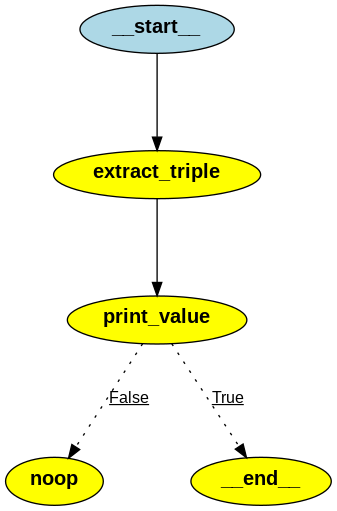

In [9]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_png()))

In [69]:
template = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            create_system_content(relations_description, fewshot_examples),
        ),
        ("human", "{text}"),
    ]
)

prompt: ChatPromptValue = template.invoke(
    {"text": create_prompt_content("Wojciech Szczęsny jest bramkarzem Juventusu")}
)  # type:ignore

graph.invoke(
    {
        "messages": prompt.messages,
    }
)
pass

Nie ma w tym tekście żadnej relacji.
Nie ma w tym tekście żadnej relacji.
Test:  Nie można poprawić
